# Regression using Artificial Neural Networks

in this example we will use Keras to predict wages based on various professional and demographic factors.

In [1]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import tensorflow as tf
import matplotlib.pyplot as plt


pd.set_option('display.float_format', '{:.4f}'.format)

sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


## Load Data

In [2]:
data = pd.read_csv('data/bcn_noise_regre_ml_dataset.csv')
pd.options.display.max_columns = None

print(data)

                         road_id  noise_day  noise_evening  noise_night  \
0      13859746870_13859746860_0         55             55           50   
1       13798851565_8465472214_0         50             50           45   
2       4538123419_13734642240_0         65             65           60   
3        13845167536_847716886_0         50             50           45   
4        13845167536_253790691_0         55             55           50   
...                          ...        ...            ...          ...   
12849    8930700699_9446738721_0         55             55           50   
12850    8930700699_9446689099_0         55             55           50   
12851     559052401_3358594835_0         70             65           60   
12852     9446738720_553047568_0         55             55           50   
12853      553047566_553047568_0         55             55           50   

       road_category  dist_to_trunk  dist_to_primary  dist_to_secondary  \
0                  5    

In [3]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                12854 non-null  str    
 1   noise_day              12854 non-null  int64  
 2   noise_evening          12854 non-null  int64  
 3   noise_night            12854 non-null  int64  
 4   road_category          12854 non-null  int64  
 5   dist_to_trunk          12854 non-null  float64
 6   dist_to_primary        12854 non-null  float64
 7   dist_to_secondary      12854 non-null  float64
 8   dist_to_tertiary       12854 non-null  float64
 9   dist_to_residential    12854 non-null  float64
 10  dist_to_living_street  12854 non-null  float64
 11  signals                12854 non-null  float64
 12  transport              12854 non-null  float64
 13  pois                   12854 non-null  float64
 14  width                  12854 non-null  float64
 15  betweenness  

In [4]:
for colname, col in data.items():
  print(colname, "min_val", col.min(), "max_val", col.max())

road_id min_val 1000063828_30251181_0 max_val 998768350_330418566_0
noise_day min_val 35 max_val 75
noise_evening min_val 35 max_val 70
noise_night min_val 35 max_val 65
road_category min_val 1 max_val 6
dist_to_trunk min_val 0.0 max_val 3795.63697068363
dist_to_primary min_val 0.0 max_val 4669.844695282637
dist_to_secondary min_val 0.0 max_val 2567.1400763731
dist_to_tertiary min_val 0.0 max_val 1060.9170816233134
dist_to_residential min_val 0.0 max_val 725.1111796739175
dist_to_living_street min_val 0.0 max_val 2415.8281661353403
signals min_val 0.0 max_val 0.1673073764890381
transport min_val 0.0 max_val 0.0535129983168081
pois min_val 0.0 max_val 0.4273687468542714
width min_val 0.0652416195278164 max_val 50.0
betweenness min_val 0.0 max_val 0.0898145310446017
closeness_global min_val 6.86461180242576e-05 max_val 0.0002429251115713
closeness_400 min_val 3.498912011162279e-07 max_val 5.625995621948065e-05
straightness min_val 0.4666823551059589 max_val 0.8841003261519561
green min_v

In [5]:
data.describe()

,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
count,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000,12854.0000
mean,59.6612,57.8972,52.9835,4.6414,1522.1815,768.9781,356.6494,134.6777,12.6826,143.5003,0.0393,0.0135,0.0358,28.3609,0.0046,0.0002,0.0000,0.8237,8.4443,3.1231,0.8607
std,7.1618,7.1158,7.0046,0.9837,872.1505,780.3334,395.6262,158.0867,39.7191,263.7175,0.0529,0.0177,0.0703,14.3977,0.0086,0.0000,0.0000,0.0561,17.5060,15.6683,5.9707
min,35.0000,35.0000,35.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0652,0.0000,0.0001,0.0000,0.4667,0.0000,0.0000,0.0000
25%,55.0000,55.0000,50.0000,4.0000,806.5921,225.5912,62.5694,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,16.0155,0.0003,0.0002,0.0000,0.8203,0.0000,0.0000,0.0000
50%,60.0000,60.0000,55.0000,5.0000,1483.0273,545.0051,241.3776,94.8014,0.0000,72.6250,0.0161,0.0068,0.0066,26.7334,0.0012,0.0002,0.0000,0.8368,0.6571,0.0000,0.0000
75%,65.0000,65.0000,60.0000,5.0000,2255.9891,1072.1296,514.5585,206.9511,0.0000,169.1780,0.0575,0.0209,0.0427,40.4701,0.0045,0.0002,0.0000,0.8497,8.8909,0.0000,0.0000
max,75.0000,70.0000,65.0000,6.0000,3795.6370,4669.8447,2567.1401,1060.9171,725.1112,2415.8282,0.1673,0.0535,0.4274,50.0000,0.0898,0.0002,0.0001,0.8841,100.0000,100.0000,100.0000


## Prepare Data

In [6]:
# Select the (independant) features that we are going to use to train the model
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) # keep only features

# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scalerX = StandardScaler()

# Apply the scaler to our X-features
X_scaled = scalerX.fit_transform(X)

print(X_scaled.shape)
X.head()

(12854, 18)


,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,5,213.0932,509.6285,1110.0523,188.3552,0.0000,385.6128,0.0533,0.0000,0.1066,50.0000,0.0000,0.0002,0.0000,0.8078,3.3493,0.0000,0.0000
1,5,173.0780,1621.6810,2110.5304,351.7774,0.0000,117.6693,0.0000,0.0143,0.0000,20.0061,0.0002,0.0001,0.0000,0.7414,0.0000,0.0000,0.0000
2,3,904.1185,947.1548,0.0000,167.0266,0.0000,19.8102,0.1673,0.0000,0.2955,50.0000,0.0105,0.0002,0.0000,0.8313,8.6192,0.0000,0.0000
3,5,1877.6035,414.6484,661.5874,10.5974,0.0000,41.3657,0.0000,0.0125,0.0025,16.7595,0.0044,0.0002,0.0000,0.7572,4.3467,0.0000,0.0000
4,5,1872.1775,607.1442,967.7465,0.0000,0.0000,49.1096,0.0000,0.0535,0.0000,50.0000,0.0037,0.0002,0.0000,0.7368,25.1696,0.0000,0.0000


In [13]:
# Define the dependant variable / target to predict
y_reg = data.noise_day

y_reg = y_reg.values.reshape(-1,1)

from sklearn.preprocessing import MinMaxScaler
scalerY = MinMaxScaler()

#In this case it makes sense to use MinMax scaling because the noise levels seem like a relative range
# Apply the scaler to our Y-features
y_scaled = scalerY.fit_transform(y_reg)

print(y_scaled.shape)

(12854, 1)


**SPLIT INTO TRAIN AND TEST**

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size = 0.2, random_state = 21)

In [15]:
#visualize our data
#we can see that scikitlearn doesnt care if it is a dataframe or a numpy array, because they all function on the same way
print("TRAIN", "input", X_train.shape, "output", y_train.shape)
print("TEST", "input", X_test.shape, "output", y_test.shape)


TRAIN input (10283, 18) output (10283, 1)
TEST input (2571, 18) output (2571, 1)


# Build model

From the cheatSheet
Regression between 0 and 1>>  
      activation = relu for hidden layers / sigmoid for final layer  
      loss = mean squared error  
      optimizer = adam  
      input from data, is 18 columns  
      output is 1 value prediction

In [24]:
# Instantiate a sequential model
model = tf.keras.models.Sequential()
n_cols = X_scaled.shape[1]
print("n_cols", n_cols)

model.add(tf.keras.layers.Dense(32, input_shape=(n_cols,), activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))

# Add a dense layer with 1 value output
model.add(tf.keras.layers.Dense(1, activation= "sigmoid"))

# Compile your model
model.compile(
    optimizer = "adam", 
    loss = "mean_squared_error",
    metrics=["accuracy"])

n_cols 18


c:\Users\cutro\miniconda3\envs\data_encoding\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

# Train model

In [26]:
# Fit your model to the training data for 200 epochs
#we assign this to history variable so we can plot the training data
history = model.fit(X_train, y_train, epochs=200, validation_split=0.2)

Epoch 1/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0051 - loss: 0.0234 - val_accuracy: 0.0102 - val_loss: 0.0181
Epoch 2/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.0125 - loss: 0.0171 - val_accuracy: 0.0102 - val_loss: 0.0163
Epoch 3/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0123 - loss: 0.0160 - val_accuracy: 0.0102 - val_loss: 0.0156
Epoch 4/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.0126 - loss: 0.0152 - val_accuracy: 0.0102 - val_loss: 0.0150
Epoch 5/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.0126 - loss: 0.0148 - val_accuracy: 0.0107 - val_loss: 0.0148
Epoch 6/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.0126 - loss: 0.0144 - val_accuracy: 0.0102 - val_loss: 0.0146
Epoch 7/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0128 - loss: 0.0141 - val_accuracy: 0.0102 - val_loss: 0.0143
Epoch 8/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.0129 - loss: 0.0139 

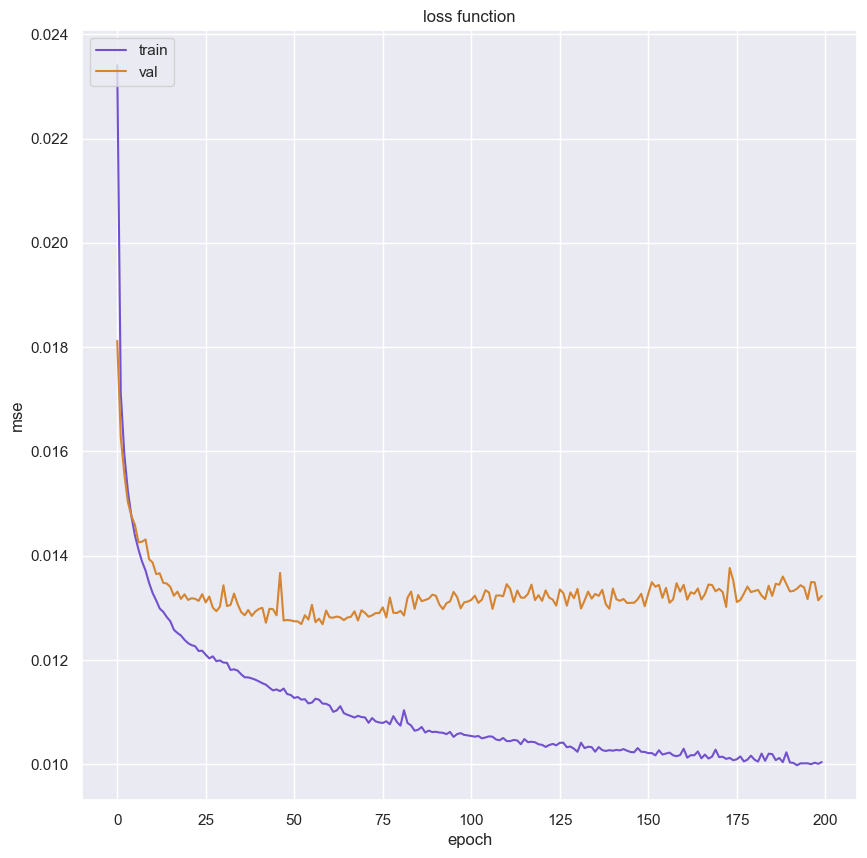

In [27]:
# summarize history for loss
plt.plot(history.history['loss'], color='#7251ce')
plt.plot(history.history['val_loss'], color='#d58430')
plt.title('loss function')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Evaluate model on test data



In [20]:
# Evaluate your model accuracy on the test data
loss_test = model.evaluate(X_test,y_test)

# Print accuracy
print('mse_test:', loss_test)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.0143
mse_test: 0.01429042313247919


In [35]:
# Model performance on the test-set / This score is R^2
#print(model.score(X_train, y_train))
print(history.model.score(X_test, y_test))

AttributeError: 'Sequential' object has no attribute 'score'

# Plot error


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


Text(0, 0.5, 'y_pred (dB)')

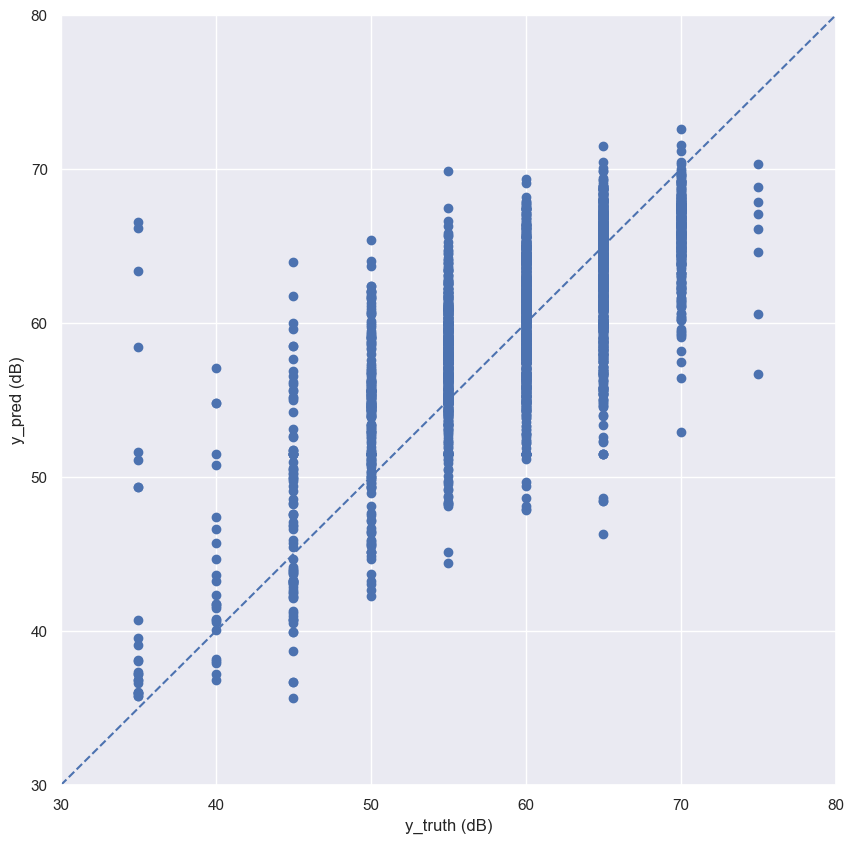

In [29]:
y_pred = scalerY.inverse_transform(model.predict(X_test))
y_truth = scalerY.inverse_transform(y_test)

plt.scatter(y_truth,y_pred)
plt.ylim((30,80))
plt.xlim((30,80))
plt.axline((0,0), slope = 1, ls="--")


plt.xlabel("y_truth (dB)")
plt.ylabel("y_pred (dB)")


In [30]:
def plot_comparison(x_val, pred, truth, xlab, ylab):
  fig, ax1 = plt.subplots(figsize = (10,10))
  ax1.plot(x_val, truth, color = "red", label = "truth",linestyle='None', marker = "o", markersize = 5)
  ax1.plot(x_val, pred, color = "blue", label = "pred",linestyle='None', marker = "o", markersize = 4, alpha = 0.5)

  ax1.set_xlabel(xlab)
  ax1.set_ylabel(ylab)
  ax1.legend()
  plt.title('Prediction Comparison')
  plt.show()

[  0.         153.9541579    0.         ... 122.6239207  393.79036703
   0.        ]


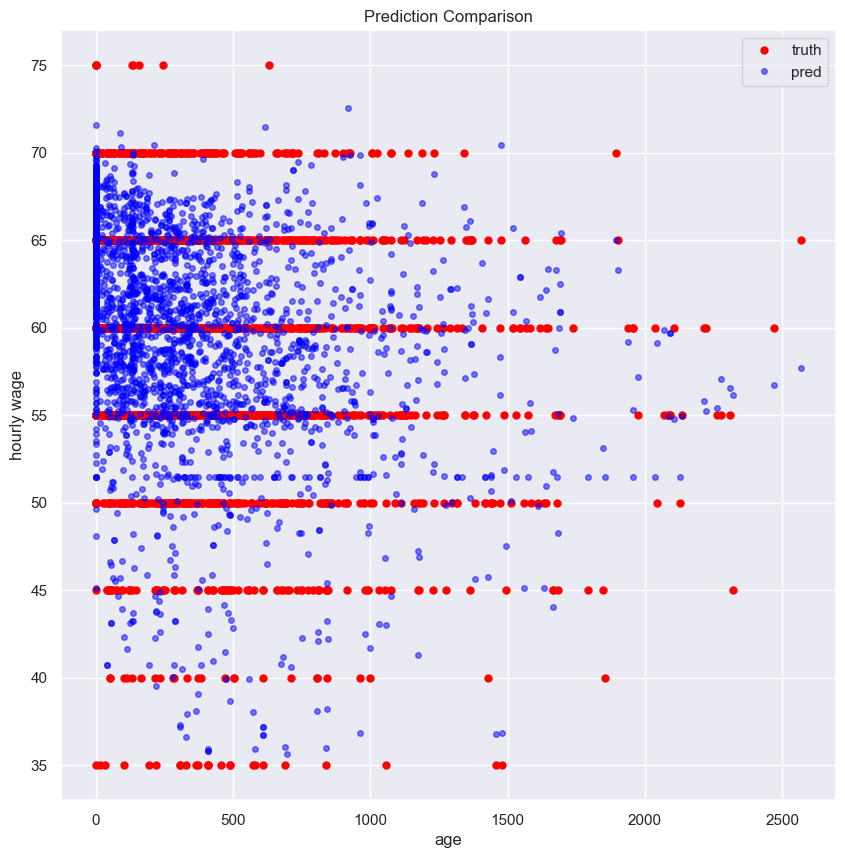

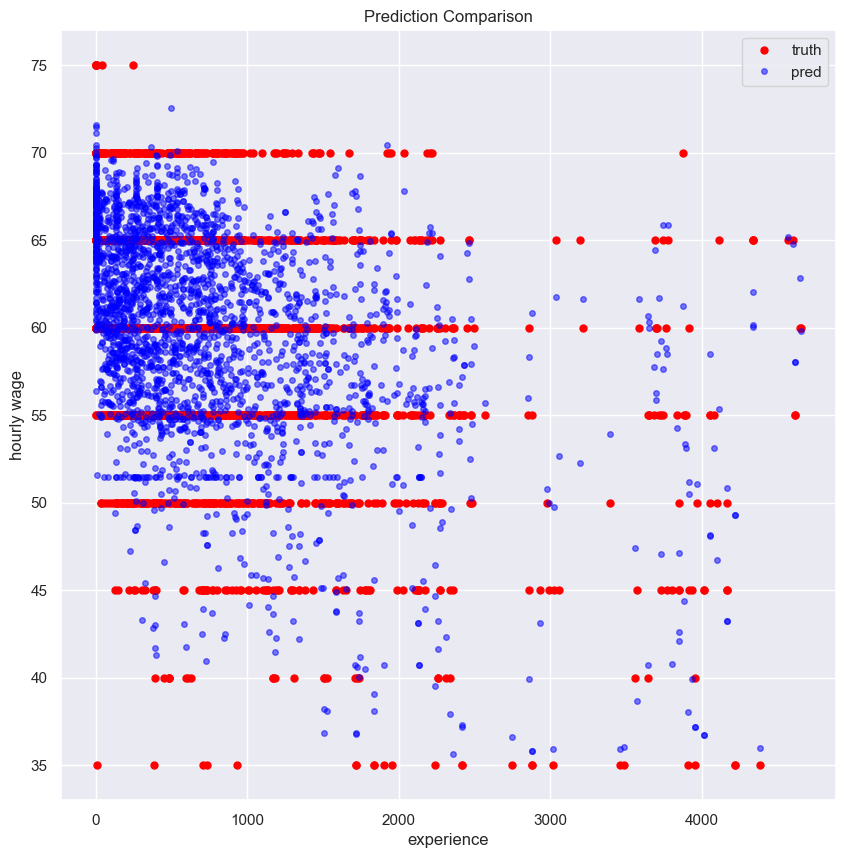

In [31]:
age_test = (scalerX.inverse_transform(X_test)[:,3])
print(age_test)

exp_test = (scalerX.inverse_transform(X_test)[:,2])

plot_comparison(age_test, y_pred, y_truth, "age", "hourly wage")
plot_comparison(exp_test, y_pred, y_truth,  "experience", "hourly wage")

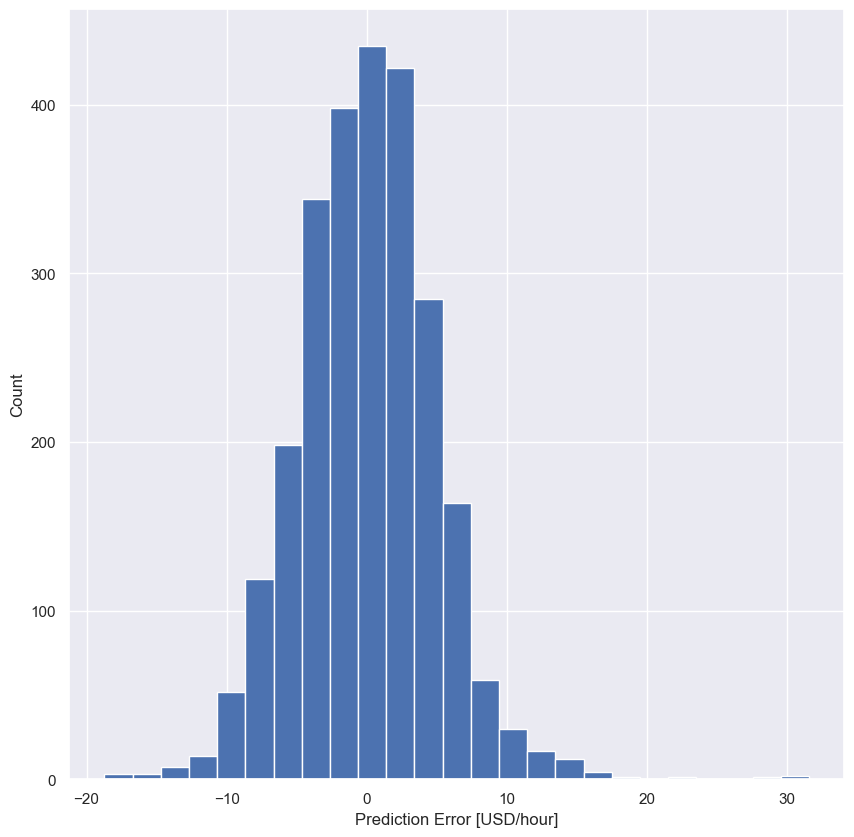

In [32]:
error = y_pred - y_truth
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [USD/hour]')
_ = plt.ylabel('Count')